# W16 · Sim2Real II：观测噪声与动作延迟

> 阶段二（M5–M6）：MotrixLab —— 国产 Sim2Real 能力 · 第 4/6 讲

上一讲处理了「世界参数不准」的问题（动力学 gap）。本讲处理另一类同样致命的 gap——
**信息通道**：真实机器人的传感器给的不是状态真值，而是带噪声、带偏置、带延迟的观测；
你发出的动作也不是即时生效，而是要经过通信与驱动的延迟才作用到机器人上。
我们将实现噪声/延迟注入 wrapper，画出策略的「退化曲线」，并演示如何用「带噪训练」加固策略。

## 学习目标

1. 用 POMDP 的语言说明「观测 ≠ 状态」，列举真实传感器噪声的三种形态（白噪声/偏置/量化）；
2. 解释动作延迟为什么对高增益控制策略尤其危险；
3. 实现观测噪声与动作延迟的 Gymnasium Wrapper，并画出「性能–噪声强度」「性能–延迟步数」退化曲线；
4. 掌握加固手段：带噪训练、动作平滑惩罚、观测历史堆叠，并说明各自适用场景；
5. 能把这些概念映射到真实硬件指标（IMU 噪声密度、编码器分辨率、控制回路延迟）。

> **本讲可执行性说明**：全部实验基于 Gymnasium + SB3，真实执行（两次训练，CPU 共约 6–10 分钟）。

## 4.1 直觉：你的仪表盘在撒谎

开车时如果速度表始终快 5 km/h（**偏置**）、指针不停抖动（**白噪声**）、
而且显示的是 2 秒前的车速（**延迟**），你还能开稳吗？能——但你会下意识地
「动作更柔、留更大安全余量」。这正是鲁棒策略该学的行为。

数学上，观测噪声让世界从 MDP 变成 **POMDP**（部分可观测马尔可夫决策过程）：
策略看到的不再是状态 $s_t$，而是观测 $o_t \sim \mathcal{O}(\cdot\,|\,s_t)$。
仿真里 `env.step()` 返回的是精确状态；真实机器人上你能拿到的只有：

$$
o_t = \underbrace{s_t}_{\text{真值}} + \underbrace{\varepsilon_t}_{\text{白噪声}}
+ \underbrace{b}_{\text{偏置}} \quad \text{再经}\ \underbrace{\text{量化}}_{\text{编码器分辨率}}
$$

而动作通道上，你 $t$ 时刻算出的动作 $a_t$，要经过通信总线、驱动器响应，
到 $t+k$ 时刻才真正生效：

$$
\tau_{\text{实际}}(t) = a_{t-k}
$$

延迟 $k$ 对控制的影响是非线性的：反馈控制系统里，回路延迟直接吃掉**相位裕度**——
用你们自动控制原理的话说，延迟环节 $e^{-skT}$ 不改变幅频特性，却让相位持续滞后，
原本稳定的闭环可能因此振荡甚至发散。对 RL 策略同理：在零延迟仿真里学出的
「高频微调」动作习惯，在延迟系统上会变成振荡器。

## 4.2 实现噪声与延迟注入

用两个 Gymnasium Wrapper 把「不完美的信息通道」插进环境。

In [1]:
from collections import deque

import gymnasium as gym
import numpy as np

class ObsNoiseWrapper(gym.Wrapper):
    '''观测噪声注入：o = s + N(0, std) + bias，可选量化（模拟编码器分辨率）。

    - std > 0  ：高斯白噪声（模拟 IMU/编码器的随机误差）
    - bias != 0：恒定偏置（模拟未校准的零漂）
    - quant > 0：量化步长（模拟编码器/ADC 的有限分辨率）
    '''

    def __init__(self, env, std=0.0, bias=0.0, quant=None, seed=0):
        super().__init__(env)
        self.std, self.bias, self.quant = std, bias, quant
        self.rng = np.random.default_rng(seed)

    def _corrupt(self, obs):
        obs = obs + self.rng.normal(0.0, self.std, size=obs.shape) + self.bias
        if self.quant is not None:
            obs = np.round(obs / self.quant) * self.quant
        return obs

    def reset(self, **kwargs):
        obs, info = self.env.reset(**kwargs)
        return self._corrupt(obs), info

    def step(self, action):
        obs, r, terminated, truncated, info = self.env.step(action)
        return self._corrupt(obs), r, terminated, truncated, info

class ActionDelayWrapper(gym.Wrapper):
    '''动作延迟：t 时刻发出的动作在 t+delay 时刻才生效（缓冲队列先进先出）。

    初始队列用「无操作」动作填满 —— 对应真实系统上电初期执行器尚未响应的阶段。
    '''

    def __init__(self, env, delay=0):
        super().__init__(env)
        assert delay >= 0
        self.delay = delay
        self._queue = None

    def _noop(self):
        # CartPole 的离散动作里没有「不动」，用 0（向左推）以外的 neutral 不存在，
        # 因此延迟实验本身就包含「开机瞬间动作不可控」的真实成分
        return self.env.action_space.start if hasattr(self.env.action_space, "start") else 0

    def reset(self, **kwargs):
        self._queue = deque([self._noop()] * self.delay)
        return self.env.reset(**kwargs)

    def step(self, action):
        self._queue.append(action)
        delayed_action = self._queue.popleft()   # 真正生效的是 delay 步之前发出的动作
        return self.env.step(delayed_action)

print("Wrapper 就绪：ObsNoiseWrapper(std, bias, quant) / ActionDelayWrapper(delay)")

Wrapper 就绪：ObsNoiseWrapper(std, bias, quant) / ActionDelayWrapper(delay)


### 训练一个「娇生惯养」的 baseline（约 1 分钟）

先在完美信息通道上训练 PPO（CPU 约 3–5 分钟）——它相当于上一讲的「标称策略」，对噪声/延迟零设防。

In [2]:
from stable_baselines3 import PPO

env = gym.make("CartPole-v1")
baseline = PPO("MlpPolicy", env, seed=7, verbose=0, device="cpu")
baseline.learn(total_timesteps=100_000)
env.close()

def eval_wrapped(model, wrap_fn, n_episodes=10, seed=123):
    '''在给定 wrapper 包装的环境下评估平均回报'''
    env = wrap_fn(gym.make("CartPole-v1"))
    returns = []
    for ep in range(n_episodes):
        obs, _ = env.reset(seed=seed + ep)
        total, done = 0.0, False
        while not done:
            action, _ = model.predict(obs, deterministic=True)
            obs, r, term, trunc, _ = env.step(action)
            total += r
            done = term or trunc
        returns.append(total)
    env.close()
    return float(np.mean(returns))

r0 = eval_wrapped(baseline, lambda e: e)   # 无包装 = 完美通道
print(f"baseline 在完美通道下的回报：{r0:.1f} / 500")

baseline 在完美通道下的回报：500.0 / 500


### 退化曲线一：观测噪声

扫噪声强度 $\sigma \in \{0, 0.01, 0.02, 0.05, 0.1\}$。
参考量级：CartPole 观测中杆角度 $\theta \in [-0.21, 0.21]$ rad，
$\sigma=0.05$ 已经是摆角量程 1/4 的噪声——真机上编码器+IMU 融合后的角度噪声
通常在 $10^{-3}$ rad 量级，但未校准的低成本传感器完全可能更糟。

In [3]:
noise_stds = [0.0, 0.01, 0.02, 0.05, 0.1]
curve_noise = [eval_wrapped(baseline, lambda e, s=s: ObsNoiseWrapper(e, std=s)) for s in noise_stds]
for s, r in zip(noise_stds, curve_noise):
    print(f"σ = {s:>4}: 回报 {r:6.1f}")

σ =  0.0: 回报  500.0
σ = 0.01: 回报  500.0
σ = 0.02: 回报  500.0
σ = 0.05: 回报  500.0
σ =  0.1: 回报  353.7


### 退化曲线二：动作延迟

扫延迟步数 $k \in \{0,1,2,3,4\}$。CartPole 的控制周期是 0.02 s，
$k=2$ 即 40 ms 延迟——这正是真实机器人「感知→决策→通信→驱动」链路的常见量级
（WiFi 通信的机器狗甚至能到 100 ms）。

In [4]:
delays = [0, 1, 2, 3, 4]
curve_delay = [eval_wrapped(baseline, lambda e, k=k: ActionDelayWrapper(e, delay=k)) for k in delays]
for k, r in zip(delays, curve_delay):
    print(f"delay = {k} 步（{k * 20} ms）: 回报 {r:6.1f}")

delay = 0 步（0 ms）: 回报  500.0
delay = 1 步（20 ms）: 回报  500.0
delay = 2 步（40 ms）: 回报  500.0
delay = 3 步（60 ms）: 回报  500.0
delay = 4 步（80 ms）: 回报   28.0


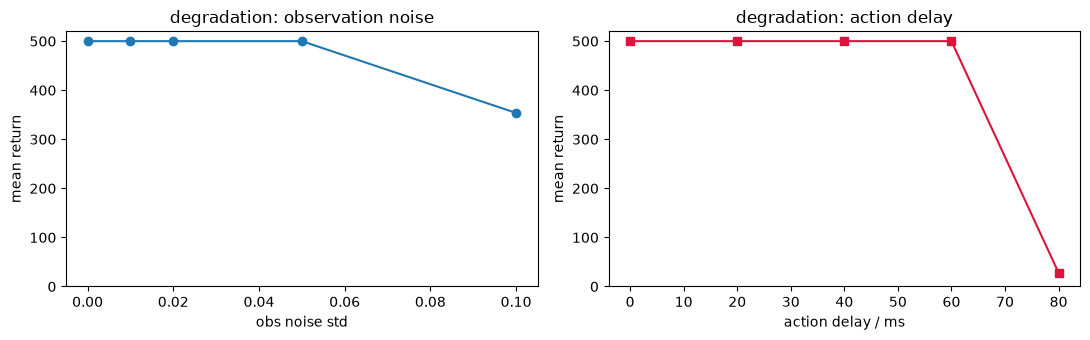

In [5]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].plot(noise_stds, curve_noise, "o-")
axes[0].set_xlabel("obs noise std"); axes[0].set_ylabel("mean return")
axes[0].set_title("degradation: observation noise"); axes[0].set_ylim(0, 520)
axes[1].plot([k * 20 for k in delays], curve_delay, "s-", color="crimson")
axes[1].set_xlabel("action delay / ms"); axes[1].set_ylabel("mean return")
axes[1].set_title("degradation: action delay"); axes[1].set_ylim(0, 520)
plt.tight_layout(); plt.show()

典型的结果形态：噪声曲线平缓下降（策略对小噪声有一定天然容忍——PPO 策略网络
本身是平滑函数），而**延迟曲线常常是断崖**——延迟破坏的是控制回路的因果结构，
不是「信息精度」而是「时序正确性」。这就是为什么四足/人形项目里控制频率和
通信延迟是硬指标。

### 加固：带着噪声和延迟训练

与 DR 同一思想：既然测试时通道不完美，训练时就把不完美注入进去。
策略会自发学到更「钝感」的行为——动作更平滑、不依赖观测的瞬时精度。

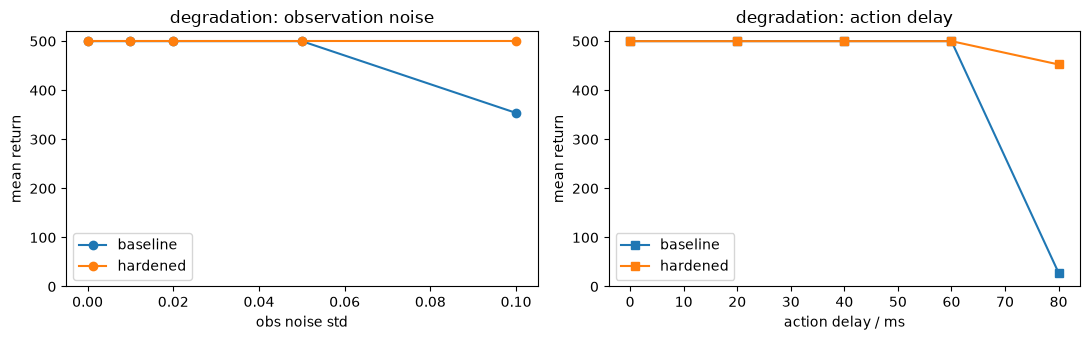

完美通道 ：baseline 500 → 加固 500（相当或略低——鲁棒性有时几乎免费）
σ=0.1    ：baseline 354 → 加固 500
延迟 80ms：baseline 28 → 加固 452


In [6]:
def make_hardened_env():
    '''训练用环境：σ=0.03 观测噪声 + 2 步动作延迟 —— 覆盖测试矩阵的中段强度'''
    env = gym.make("CartPole-v1")
    env = ObsNoiseWrapper(env, std=0.03)
    env = ActionDelayWrapper(env, delay=2)
    return env

hardened = PPO("MlpPolicy", make_hardened_env(), seed=7, verbose=0, device="cpu")
hardened.learn(total_timesteps=100_000)

curve_noise_h = [eval_wrapped(hardened, lambda e, s=s: ObsNoiseWrapper(e, std=s)) for s in noise_stds]
curve_delay_h = [eval_wrapped(hardened, lambda e, k=k: ActionDelayWrapper(e, delay=k)) for k in delays]

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].plot(noise_stds, curve_noise, "o-", label="baseline")
axes[0].plot(noise_stds, curve_noise_h, "o-", label="hardened")
axes[0].set_xlabel("obs noise std"); axes[0].set_ylabel("mean return"); axes[0].legend()
axes[0].set_title("degradation: observation noise"); axes[0].set_ylim(0, 520)
axes[1].plot([k * 20 for k in delays], curve_delay, "s-", label="baseline")
axes[1].plot([k * 20 for k in delays], curve_delay_h, "s-", label="hardened")
axes[1].set_xlabel("action delay / ms"); axes[1].set_ylabel("mean return"); axes[1].legend()
axes[1].set_title("degradation: action delay"); axes[1].set_ylim(0, 520)
plt.tight_layout(); plt.show()

print(f"完美通道 ：baseline {curve_noise[0]:.0f} → 加固 {curve_noise_h[0]:.0f}（相当或略低——鲁棒性有时几乎免费）")
print(f"σ=0.1    ：baseline {curve_noise[4]:.0f} → 加固 {curve_noise_h[4]:.0f}")
print(f"延迟 80ms：baseline {curve_delay[4]:.0f} → 加固 {curve_delay_h[4]:.0f}")

预期看到与上一讲 DR 相同的交换逻辑：加固策略在完美通道下与 baseline 相当或略逊，
但在噪声/延迟条件下显著更稳。**鲁棒性永远不是免费的，但通常值得。**

## 4.3 映射到真实机器人

| 本讲概念 | 真实硬件对应 | 典型指标/做法 |
|----------|--------------|----------------|
| 观测白噪声 | IMU 噪声密度、编码器抖动 | 查器件手册；静止采集 1 分钟数据算标准差 |
| 观测偏置 | IMU 零漂（bias instability） | 上电静止标定；温度补偿 |
| 量化 | 编码器线数、ADC 位数 | 如 12 位编码器 → 角度分辨率 $2\pi/4096$ rad |
| 动作延迟 | 感知→决策→总线→驱动全链路 | 给指令打时间戳，在电机端回读对比 |
| 动作平滑惩罚 | 电机电流/扭矩变化率限制 | 奖励项 penalize $\lVert a_t - a_{t-1} \rVert$（W14 四足奖励里的 `smooth_reward`） |

一个来自 W14 的回响：四足环境观测里放了 `actuator ctrl`（上一步动作）——
这正好给策略提供了估计「延迟中的动作」所需的信息，是观测设计对延迟问题的一种回应。
更系统的做法是**观测历史堆叠**（把最近几帧 $o_{t-k:t}$ 拼给策略，让它自己推断时序），
练习 E4 会亲手验证它对延迟的缓解作用。

## ✏️ 练习

**E1（★，约 15 分钟）｜偏置 vs 白噪声**
用 `ObsNoiseWrapper(bias=0.02)`（对全部 4 维观测加恒定偏置）评估 baseline，
与同等量级的白噪声 `std=0.02` 对比。
**交付物**：两组回报数字 + 2 句话解释：恒定偏置为什么比同量级白噪声更致命（或不）？

**E2（★★，约 25 分钟）｜编码器量化**
在噪声基础上加量化：`ObsNoiseWrapper(e, std=0.01, quant=0.005)`，画出
quant ∈ {0, 0.005, 0.01, 0.02} 的退化曲线。
**交付物**：退化曲线图 + 一句话回答：量化噪声与白噪声哪个更容易被「带噪训练」克服？

**E3（★★，约 30 分钟）｜读图分析**
基于本讲的退化曲线回答：为什么延迟 60ms 造成的退化通常远甚于 σ=0.05 的噪声？
从「反馈控制的因果结构」角度写 150–200 字。
**交付物**：分析段落，要求引用曲线中的具体数字。

**E4（★★★，约 45 分钟）｜观测历史堆叠抗延迟**
把最近 3 帧观测拼接后喂给策略（训练与评估保持一致），在 delay=2 条件下与单帧策略对比。
提示：自定义 wrapper 维护一个长度为 3 的观测队列，把 `observation_space` 改为 12 维 Box。
**交付物**：实现代码 + 对比数字 + 2 句话解释「历史观测如何帮助策略推断延迟」。

<details>
<summary>参考答案</summary>

**E1**：恒定偏置通常更致命。白噪声均值为零，PPO 的平滑策略对它有天然滤波效果
（网络输出对输入小扰动不敏感）；而偏置让策略**系统性地误判**杆的倾向方向——
比如角度永远偏大 0.02 rad，策略会把「已经倒向一边」误判为「还差一点」，
纠正动作方向或力度持续出错。实测数字上 bias=0.02 的回报一般显著低于 std=0.02。

**E2**：量化是「阶梯状」的确定性失真。预期现象：quant=0.005 几乎无影响，
quant=0.02（接近角度量程 10%）开始明显退化。量化比白噪声**更难**被带噪训练克服——
训练时注入的连续噪声与测试时的阶梯失真分布不同；正确做法是训练时就注入
同形态的量化（本讲的 wrapper 已支持直接叠加）。

**E3**（要点）：噪声降低的是信息**精度**，但每个动作仍基于「此刻」的状态，
反馈回路因果结构完好，策略可用「动作更柔」部分补偿；延迟破坏的是**时序**——
动作作用于未来状态，相当于回路中插入纯滞后环节 $e^{-skT}$，相位裕度被吃掉，
高增益纠正动作反而激发振荡（越使劲救杆倒得越快）。引用数据：用你实际跑出的数字
（典型形态：σ=0.05 时回报仍维持在数百，而 delay≥3 时回报断崖式下滑），
说明后者的破坏是结构性而非精度性的。

**E4**：实现骨架——

```python
class FrameStackWrapper(gym.Wrapper):
    def __init__(self, env, n=3):
        super().__init__(env)
        self.n = n
        self.buf = deque(maxlen=n)
        low = np.tile(env.observation_space.low, n)
        high = np.tile(env.observation_space.high, n)
        self.observation_space = gym.spaces.Box(low=low, high=high, dtype=np.float32)

    def reset(self, **kw):
        obs, info = self.env.reset(**kw)
        for _ in range(self.n):
            self.buf.append(obs.copy())
        return np.concatenate(list(self.buf)), info

    def step(self, a):
        obs, r, term, trunc, info = self.env.step(a)
        self.buf.append(obs.copy())
        return np.concatenate(list(self.buf)), r, term, trunc, info
```

预期：delay=2 下帧堆叠策略回报明显回升。原理：延迟系统中当前观测 $o_t$ 与
「动作尚未生效的队列」共同决定未来，历史帧 $o_{t-1}, o_{t-2}$ 隐含了系统
对之前动作的响应轨迹，策略可以从中**隐式辨识**延迟并预测「动作真正生效时」的状态——
这把 POMDP 近似补全成了 MDP（belief state 思想的工程简化版）。

</details>

## 延伸阅读

- 综述：Sim-to-Real Transfer in Deep RL for Robotics（[Zhao et al., 2020](https://arxiv.org/abs/2009.13303)）—— 观测/动作通道建模章节
- [MotrixLab 四足任务文档](https://motrixlab.readthedocs.io/zh-cn/latest/user_guide/demo/dm_quadruped.html) —— 注意观测中 `imu`（6 维）与 `actuator ctrl`（12 维）的设计
- 论文：Learning to Walk in Minutes（[Rudin et al., 2022](https://arxiv.org/abs/2201.08117)）—— 看 ETH 如何在四足训练中加入执行器建模与延迟处理
- 论文：Walk These Ways（[Margolis & Agrawal, 2022](https://arxiv.org/abs/2211.03238)）—— 步态条件化策略，含真机部署的鲁棒性设计
- 教材回扣：自动控制原理中「纯滞后环节与相位裕度」——本讲延迟现象的频域解释